# NeuralGCM lead-time ensemble sweep - St. John's heat wave

*(resumable build template)*

This version is engineered so a **Colab disconnect never costs you more than one lead**, and
so the headline number carries an uncertainty estimate.

### Notes & Warnings:
1. Requires a STOCHASTIC checkpoint
   
   NeuralGCM ensemble spread comes from the stochastic model component, seeded by the
`encode` rng key. With a **deterministic** checkpoint the key is inert and every member
is identical (zero spread). This notebook defaults to `v1/stochastic_1_4_deg.pkl` and
checks the spread after the first lead — heed the error if it fires.

2. Run all. Drive is mounted, ERA5 is loaded/cached once; **members are batched with `jax.vmap`**. 
   If interrupted, just **Run all again** - finished leads resume from Drive. To test the cheaper,
   grid-matched model, set `USE_2_8_DEG = True` in Config.

> **Still open (not fixed here):** the hit rate is scored against ERA5 *on the model grid*,
> which at this resolution is a cool, partly-oceanic T₁₀₀₀ (~20 °C) — far below the observed
> 30.9 °C. So a high hit rate means "tracks the coarse-grid ERA5 signal", **not** "reproduces
> the 30.9 °C heat wave". The variable is named `GRID_PEAK_TOL` to reflect this honestly.
> Anomaly-space scoring is the real fix — ask for that variant.

In [2]:
# Check connect device
import jax
print(jax.devices())

[CudaDevice(id=0)]


In [3]:
# Install required stack
!pip install -q -U neuralgcm dinosaur gcsfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.7/195.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 152.5 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is

In [ ]:
# import required libraries
import gc  # garbage collector
import gcsfs  # google cloud storage filesystem
import jax
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
import neuralgcm

# atmospheric/dynamical-core computation
from dinosaur import horizontal_interpolation, spherical_harmonic, xarray_utils

In [6]:
print("JAX devices:", jax.devices())
if not any(d.platform in ("gpu", "cuda") for d in jax.devices()):
    print("\u26a0\ufe0f  No GPU detected \u2014 Runtime \u25b8 Change runtime type \u25b8 GPU, then Run all.")

JAX devices: [CudaDevice(id=0)]


In [ ]:
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.titlesize": 11})

## Checkpointing

All expensive artifacts (the regridded ERA5 window and each lead's ensemble trajectories)
are written here. 

On a fresh session this mounts Drive and creates the checkpoint folder; on
a reconnect it finds the existing files and the sweep resumes. If you are **not** on Colab,
set `USE_DRIVE = False` and everything falls back to a local `./heatwave_ckpt` directory
(which does *not* survive a VM reset, but keeps the code runnable off-Colab).

In [11]:
from pathlib import Path

# False -> local ./heatwave_ckpt WHERE THE KERNEL LIVE
USE_DRIVE = True

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        CKPT = Path("/content/drive/MyDrive/heatwave_ckpt")
    except Exception as e:
        print("Drive mount failed, falling back to local dir:", e)
        CKPT = Path("heatwave_ckpt")
else:
    CKPT = Path("heatwave_ckpt")

CKPT.mkdir(parents=True, exist_ok=True)
print("Checkpoint dir:", CKPT.resolve())

Mounted at /content/drive
Checkpoint dir: /content/drive/MyDrive/heatwave_ckpt


## Config

In [12]:
# REQUIRES A STOCHASTIC CHECKPOINT 
# ---- Model selection -------------------------------------------------
# Start by trying the 2.8° model: it is much smaller, allows a larger vmap batch,
# is grid-matched to the deterministic 2.8° sweep, and may finish the whole sweep
# in minutes. Flip this to True to use it.
USE_2_8_DEG = True

if USE_2_8_DEG:
    MODEL_NAME = "v1_precip/stochastic_precip_2_8_deg.pkl"   # smaller, grid-matched
    MEMBER_BATCH = 8     # 2.8° state is small; pack more members per vmap GPU call
else:
    # canonical stochastic model
    MODEL_NAME = "v1/stochastic_1_4_deg.pkl"
    MEMBER_BATCH = 2     # 1.4° state ~0.7 GB each; keep the device batch small

ERA5_PATH = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

# Observed St. John's Intl A daily Tmax (°C).
OBS_TMAX = {"2025-08-09": 30.5, "2025-08-10": 27.7, "2025-08-11": 28.1,
            "2025-08-12": 30.9, "2025-08-13": 30.3, "2025-08-14": 27.8,
            "2025-08-15": 29.2}
EVENT_PEAK = np.datetime64("2025-08-12")
EVENT_START = np.datetime64("2025-08-09")
EVENT_END = np.datetime64("2025-08-15")

LEAD_TIMES_DAYS = [20, 18, 16, 14, 12, 10, 9, 7, 5, 3]

# ---- Ensemble size (C1) ------------------------------------------------------
# With resumable checkpointing you can afford a larger N: the crossover's sampling
# noise shrinks as ~1/sqrt(N) and the Wilson CI (computed below) narrows. 8 resolves
# the hit rate only in steps of 0.125; 24-32 is a reasonable target. The sweep is
# resumable, so a large N that spans a disconnect is fine.
N_MEMBERS = 24

# ---- Capture threshold (C2) --------------------------------------------------
# A member "captures" if its window-peak >= GRID-SCALE ERA5 peak - GRID_PEAK_TOL.
# NOTE the honest name: this scores skill at reproducing ERA5's own coarse-grid peak
# (~20 °C), NOT the 30.9 °C station observation. See the caveat at the top.
# °C; try 1.5 / 2.0 / 3.0 and report sensitivity (cheap to re-score)
GRID_PEAK_TOL = 2.0

DATA_INNER_HOURS = 24   # 24 = daily; 6 = 6-hourly (needs High-RAM)
CHUNK_DAYS = 5    # regrid-block size; peak RAM = one block at 0.25°

STJOHNS_LAT = 47.5615
STJOHNS_LON = 360.0 - 52.7126
RNG_SEED = 42

# Per-model cache namespace so 1.4° and 2.8° artifacts never collide on Drive.
TAG = "2_8deg" if USE_2_8_DEG else "1_4deg"
LEAD_DIR = CKPT / f"leads_{TAG}"
LEAD_DIR.mkdir(parents=True, exist_ok=True)
ERA5_CACHE = CKPT / f"eval_era5_regridded_{TAG}.nc"

DATA_DIR = Path("data")
PLOTS_DIR = Path("plots")
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

print(
    f"Model: {MODEL_NAME}  |  N_MEMBERS={N_MEMBERS}  MEMBER_BATCH={MEMBER_BATCH}")
print(f"Lead cache: {LEAD_DIR}")

Model: v1_precip/stochastic_precip_2_8_deg.pkl  |  N_MEMBERS=24  MEMBER_BATCH=8
Lead cache: /content/drive/MyDrive/heatwave_ckpt/leads_2_8deg


## Load model, open ERA5, build regridder, load + regrid the window

In [13]:
print(f"Loading model {MODEL_NAME} \u2026")
gcs = gcsfs.GCSFileSystem(token="anon")
with gcs.open(f"gs://neuralgcm/models/{MODEL_NAME}", "rb") as f:
    ckpt = pickle.load(f)
model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
print("input_variables:", model.input_variables)

Loading model v1_precip/stochastic_precip_2_8_deg.pkl …
input_variables: ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']


In [14]:
print("Opening ARCO-ERA5 (lazy) \u2026")
full_era5 = xr.open_zarr(ERA5_PATH, chunks=None,
                         storage_options=dict(token="anon"))

era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes["latitude"],
    longitude_nodes=full_era5.sizes["longitude"],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True)
shifted_full = full_era5[model.input_variables + model.forcing_variables].pipe(
    xarray_utils.selective_temporal_shift,
    variables=model.forcing_variables, time_shift="24 hours")


def load_regridded(t0, t1, inner_hours, chunk_days):
    sub = (shifted_full.sel(time=slice(t0, t1))
           .isel(time=slice(None, None, inner_hours)))
    steps = max(1, chunk_days * (24 // inner_hours))
    n = sub.sizes["time"]
    pieces = []
    for i in range(0, n, steps):
        chunk = sub.isel(time=slice(i, i + steps)).compute()
        g = xarray_utils.fill_nan_with_nearest(
            xarray_utils.regrid(chunk, regridder))
        pieces.append(g)
        print(
            f"  block {i // steps + 1}: {chunk.sizes['time']:3d} snapshots regridded")
        del chunk
        gc.collect()
    return xr.concat(pieces, dim="time")


buffer = np.timedelta64(2, "D")
window_start = EVENT_PEAK - np.timedelta64(max(LEAD_TIMES_DAYS), "D")
window_end = EVENT_END + buffer

# --- A2: reuse the regridded window if a previous session already built it ---
if ERA5_CACHE.exists():
    print(f"Loading cached regridded ERA5 \u2190 {ERA5_CACHE}")
    eval_era5 = xr.open_dataset(ERA5_CACHE).load()
else:
    print(
        f"Loading + regridding ERA5 {window_start} \u2192 {window_end} \u2026")
    eval_era5 = load_regridded(
        window_start, window_end, DATA_INNER_HOURS, CHUNK_DAYS)
    eval_era5.to_netcdf(ERA5_CACHE)
    print(f"Cached regridded ERA5 \u2192 {ERA5_CACHE}")
print(f"\u2192 {eval_era5.sizes['time']} snapshots on the model grid.")


def daily_max_t1000(ds):
    pt = ds.temperature.sel(level=1000).sel(
        latitude=STJOHNS_LAT, longitude=STJOHNS_LON, method="nearest") - 273.15
    return pt.resample(time="1D").max().to_pandas()


era5_truth = daily_max_t1000(eval_era5)

Opening ARCO-ERA5 (lazy) …
Loading + regridding ERA5 2025-07-23 → 2025-08-17 …
  block 1:   5 snapshots regridded
  block 2:   5 snapshots regridded
  block 3:   5 snapshots regridded
  block 4:   5 snapshots regridded
  block 5:   5 snapshots regridded
  block 6:   1 snapshots regridded
Cached regridded ERA5 → /content/drive/MyDrive/heatwave_ckpt/eval_era5_regridded_2_8deg.nc
→ 26 snapshots on the model grid.


## Ensemble sweep: N members per lead — batched with `jax.vmap`, **resumable per lead**

Each lead is independent, so each lead's trajectory matrix is checkpointed to
`LEAD_DIR/lead_<d>.parquet` **before** scoring. On reconnect, a lead whose file exists is
loaded and skipped — the expensive NeuralGCM rollout is never repeated. Because skill scores
are cheap to recompute from trajectories, changing `GRID_PEAK_TOL` later re-scores instantly
without re-running the model.

In [15]:
td = np.timedelta64(1, "h") * DATA_INNER_HOURS


def run_lead(init_time, keys):
    # Ensemble members for one lead, vmap'd over rng keys in GPU batches of
    # MEMBER_BATCH. GPU memory ~ MEMBER_BATCH trajectories; HOST memory ~ ONE
    # member (we keep the batch on-device and pull one member at a time, because
    # each member's full model state is ~0.7 GB at 1.4 deg and materializing the
    # whole batch on host crashes Colab RAM). Only the rng key varies; IC and
    # forcings are shared (closed over).
    fc = eval_era5.sel(time=slice(init_time, window_end))
    n_steps = fc.sizes["time"]
    inputs = model.inputs_from_xarray(fc.isel(time=0))
    forcing0 = model.forcings_from_xarray(fc.isel(time=0))
    all_forcings = model.forcings_from_xarray(fc)

    def one(key):
        # stochastic seed = key
        state = model.encode(inputs, forcing0, key)
        _, preds = model.unroll(state, all_forcings, steps=n_steps,
                                timedelta=td, start_with_input=True)
        return preds

    batched_one = jax.vmap(one)
    times = fc.time.values
    members = []
    for s in range(0, keys.shape[0], MEMBER_BATCH):
        kb = keys[s:s + MEMBER_BATCH]
        # batched, kept on device
        preds_b = batched_one(kb)
        for j in range(kb.shape[0]):
            preds_m = jax.tree_util.tree_map(
                lambda x, i=j: np.asarray(x[i]), preds_b)
            ds = model.data_to_xarray(
                preds_m, times=np.arange(n_steps) * DATA_INNER_HOURS).as_numpy()
            ds = ds.assign_coords(time=times)
            members.append(daily_max_t1000(ds))
            del ds, preds_m
            gc.collect()              # free this member before the next
        del preds_b
        gc.collect()                      # free the device batch
    return members


def wilson_interval(k, n, z=1.96):
    # Wilson score 95% CI for a binomial proportion (C1). Robust at small n and
    # at p near 0/1, where the normal approximation fails. Returns (lo, hi).
    if n == 0:
        return (float("nan"), float("nan"))
    phat = k / n
    denom = 1 + z**2 / n
    centre = (phat + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


base = jax.random.key(RNG_SEED)
win = slice(pd.Timestamp(EVENT_START), pd.Timestamp(EVENT_END))
# GRID-scale ERA5 peak (see C2 caveat)
obs_peak = float(era5_truth.loc[win].max())

ens_traj, records = {}, []
_spread_checked = False
for lead in LEAD_TIMES_DAYS:
    cache_f = LEAD_DIR / f"lead_{lead}.parquet"
    if cache_f.exists():                               # A1: resume completed lead
        mat = pd.read_parquet(cache_f)
        # C3: derive count from data
        mat.columns = range(mat.shape[1])
        ens_traj[lead] = mat
        print(f"lead {lead:2d} d: loaded from cache ({mat.shape[1]} members)")
    else:
        init = EVENT_PEAK - np.timedelta64(lead, "D")
        keys = jax.random.split(jax.random.fold_in(base, int(lead)), N_MEMBERS)
        # batched in MEMBER_BATCH chunks
        members = run_lead(init, keys)
        mat = pd.concat(members, axis=1)
        mat.columns = range(len(members))  # C3
        # A1: persist BEFORE scoring
        mat.to_parquet(cache_f)
        ens_traj[lead] = mat
        print(
            f"lead {lead:2d} d: computed & cached ({mat.shape[1]} members) \u2192 {cache_f.name}")

    # --- A3: fail fast on a deterministic checkpoint, after the FIRST lead ---
    if not _spread_checked:
        if float(mat.std(axis=1).max()) < 1e-6:
            raise RuntimeError(
                "Zero ensemble spread after the first lead \u2014 members are identical. "
                "You are almost certainly using a DETERMINISTIC checkpoint. Set a stochastic "
                "MODEL_NAME (the default v1/stochastic_1_4_deg.pkl, or the 2.8° stochastic "
                "model) and re-run. Delete the cached lead_*.parquet for this TAG first.")
        _spread_checked = True

    # --- scoring (cheap; recomputed from trajectories every run) ---
    n_mem = mat.shape[1]                               # C3
    peaks = mat.loc[win].max(axis=0)                   # per-member window peak
    rmse = np.sqrt(
        (mat.loc[win].sub(era5_truth.loc[win], axis=0) ** 2).mean(axis=0))
    n_hit = int((peaks >= obs_peak - GRID_PEAK_TOL).sum())
    hit = n_hit / n_mem
    lo, hi = wilson_interval(n_hit, n_mem)             # C1
    init_date = (EVENT_PEAK - np.timedelta64(lead, "D"))
    records.append({"lead_days": lead,
                    "init_date": pd.Timestamp(init_date).date(),
                    "n_members": n_mem,
                    "hit_rate": round(hit, 3),
                    "hit_lo95": round(lo, 3), "hit_hi95": round(hi, 3),
                    "ens_mean_peak_C": round(float(peaks.mean()), 2),
                    "ens_std_peak_C": round(float(peaks.std()), 2),
                    "obs_peak_C": round(obs_peak, 2),
                    "ens_mean_rmse_C": round(float(rmse.mean()), 2)})
    print(f"          hit {hit:.2f} [{lo:.2f},{hi:.2f}]  "
          f"peak {peaks.mean():.1f}\u00b1{peaks.std():.1f} \u00b0C")
    gc.collect()

skill = pd.DataFrame(records).sort_values("lead_days").reset_index(drop=True)
skill

lead 20 d: computed & cached (24 members) → lead_20.parquet
          hit 0.00 [0.00,0.14]  peak 19.0±1.5 °C
lead 18 d: computed & cached (24 members) → lead_18.parquet
          hit 0.00 [0.00,0.14]  peak 17.5±1.9 °C
lead 16 d: computed & cached (24 members) → lead_16.parquet
          hit 0.00 [0.00,0.14]  peak 18.3±1.2 °C
lead 14 d: computed & cached (24 members) → lead_14.parquet
          hit 0.00 [0.00,0.14]  peak 18.7±1.3 °C
lead 12 d: computed & cached (24 members) → lead_12.parquet
          hit 0.04 [0.01,0.20]  peak 19.2±1.2 °C
lead 10 d: computed & cached (24 members) → lead_10.parquet
          hit 0.00 [0.00,0.14]  peak 19.4±1.1 °C
lead  9 d: computed & cached (24 members) → lead_9.parquet
          hit 0.00 [0.00,0.14]  peak 19.5±1.1 °C
lead  7 d: computed & cached (24 members) → lead_7.parquet
          hit 0.00 [0.00,0.14]  peak 19.9±0.9 °C
lead  5 d: computed & cached (24 members) → lead_5.parquet
          hit 0.04 [0.01,0.20]  peak 20.8±0.9 °C
lead  3 d: computed & 

,lead_days,init_date,n_members,hit_rate,hit_lo95,hit_hi95,ens_mean_peak_C,ens_std_peak_C,obs_peak_C,ens_mean_rmse_C
0,3,2025-08-09,24,0.000,0.000,0.138,21.17,0.18,24.42,3.46
1,5,2025-08-07,24,0.042,0.007,0.202,20.85,0.90,24.42,4.38
2,7,2025-08-05,24,0.000,0.000,0.138,19.88,0.90,24.42,5.80
3,9,2025-08-03,24,0.000,0.000,0.138,19.51,1.05,24.42,6.52
4,10,2025-08-02,24,0.000,0.000,0.138,19.43,1.07,24.42,6.51
5,12,2025-07-31,24,0.042,0.007,0.202,19.22,1.23,24.42,6.37
6,14,2025-07-29,24,0.000,0.000,0.138,18.74,1.31,24.42,7.11
7,16,2025-07-27,24,0.000,0.000,0.138,18.33,1.16,24.42,7.60
8,18,2025-07-25,24,0.000,0.000,0.138,17.55,1.88,24.42,8.39
9,20,2025-07-23,24,0.000,0.000,0.138,18.98,1.53,24.42,7.16


## Save outputs

Member count is read per-lead from the trajectory matrices, so a run that mixes cached and
freshly computed leads (possibly with different `N_MEMBERS` across sessions) still serialises
correctly. Ragged member counts are padded with NaN along a common `member` axis.

In [16]:
skill.to_csv(
    DATA_DIR / "heatwave_leadtime_ensemble_skill_aug2025.csv", index=False)

# C3: build a common member axis across leads (counts may differ between sessions).
max_members = max(mat.shape[1] for mat in ens_traj.values())
das = []
for lead, mat in ens_traj.items():
    arr = np.full((mat.shape[0], max_members), np.nan)
    arr[:, :mat.shape[1]] = mat.values
    da = xr.DataArray(arr, dims=("time", "member"),
                      coords={"time": mat.index,
                              "member": np.arange(max_members)}
                      ).expand_dims(lead_days=[lead])
    das.append(da)
ens_da = xr.concat(das, dim="lead_days")
xr.Dataset({"tmax_proxy_C": ens_da,
            "era5_tmax_proxy_C": xr.DataArray(
                era5_truth.values, coords={"time": era5_truth.index}, dims="time")}
           ).to_netcdf(DATA_DIR / "heatwave_leadtime_ensemble_aug2025.nc")
print("Saved \u2192 data/heatwave_leadtime_ensemble_skill_aug2025.csv + .nc")

Saved → data/heatwave_leadtime_ensemble_skill_aug2025.csv + .nc


/tmp/ipykernel_4220/3784024328.py:15: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ens_da = xr.concat(das, dim="lead_days")


## Plots

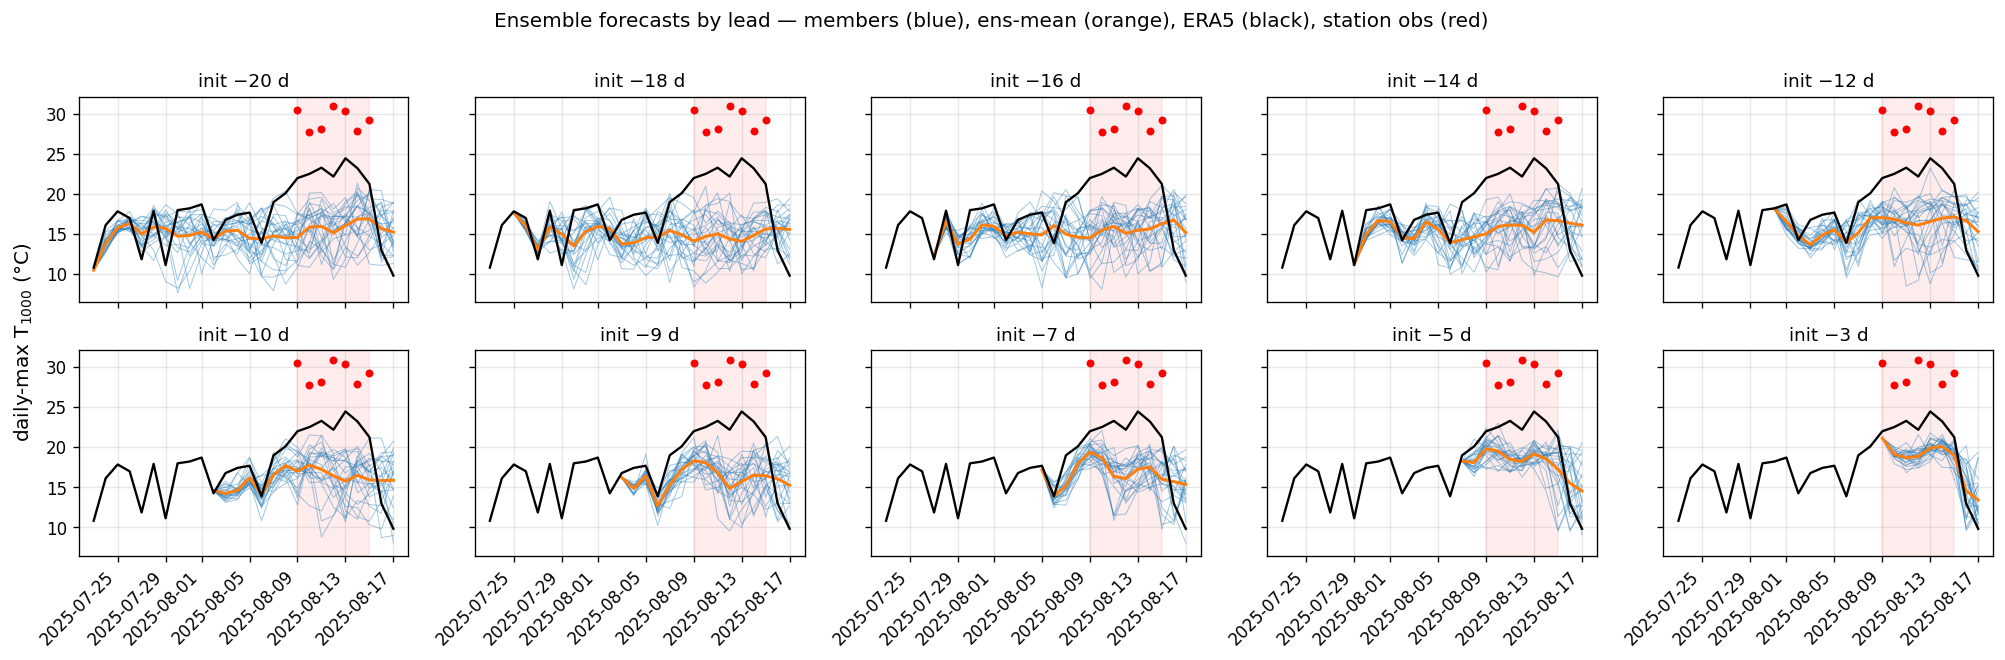

In [17]:
obs = pd.Series({pd.Timestamp(k): v for k, v in OBS_TMAX.items()}).sort_index()
leads_desc = sorted(LEAD_TIMES_DAYS, reverse=True)
n = len(leads_desc)
ncol = 5
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.7 * nrow),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, lead in zip(axes, leads_desc):
    mat = ens_traj[lead]
    for col in mat.columns:
        ax.plot(mat.index, mat[col], color="C0", lw=0.6, alpha=0.4)
    ax.plot(mat.index, mat.mean(axis=1), color="C1", lw=1.8)
    ax.plot(era5_truth.index, era5_truth.values, "k", lw=1.4)
    ax.scatter(obs.index, obs.values, c="red", s=14, zorder=5)
    ax.axvspan(pd.Timestamp(EVENT_START), pd.Timestamp(
        EVENT_END), color="red", alpha=0.07)
    ax.set_title(f"init \u2212{lead} d")
    for lab in ax.get_xticklabels():
        lab.set_rotation(45)
        lab.set_ha("right")
for ax in axes[n:]:
    ax.axis("off")
fig.supylabel("daily-max T$_{1000}$ (\u00b0C)")
fig.suptitle("Ensemble forecasts by lead \u2014 members (blue), ens-mean (orange), "
             "ERA5 (black), station obs (red)", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "heatwave_leadtime_ensemble_envelope.pdf",
            bbox_inches="tight")
plt.show()

/tmp/ipykernel_4220/949031540.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a2.boxplot(data, labels=[str(l) for l in leads_desc])


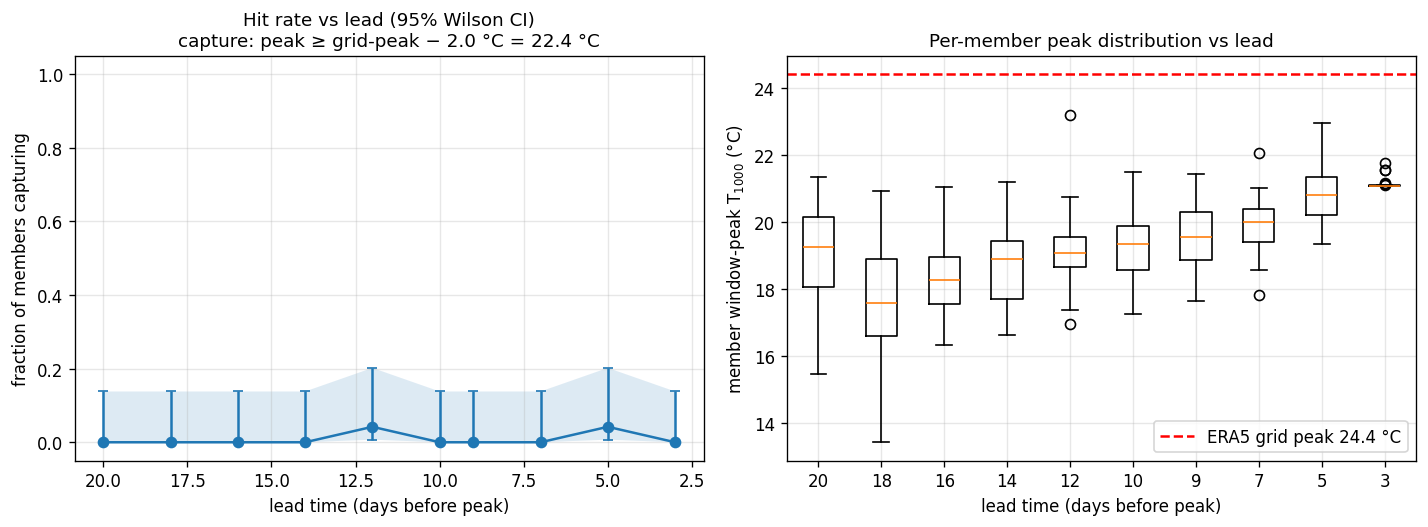

 lead_days  init_date  n_members  hit_rate  hit_lo95  hit_hi95  ens_mean_peak_C  ens_std_peak_C  obs_peak_C  ens_mean_rmse_C
         3 2025-08-09         24     0.000     0.000     0.138            21.17            0.18       24.42             3.46
         5 2025-08-07         24     0.042     0.007     0.202            20.85            0.90       24.42             4.38
         7 2025-08-05         24     0.000     0.000     0.138            19.88            0.90       24.42             5.80
         9 2025-08-03         24     0.000     0.000     0.138            19.51            1.05       24.42             6.52
        10 2025-08-02         24     0.000     0.000     0.138            19.43            1.07       24.42             6.51
        12 2025-07-31         24     0.042     0.007     0.202            19.22            1.23       24.42             6.37
        14 2025-07-29         24     0.000     0.000     0.138            18.74            1.31       24.42             7.11


In [ ]:
# C1: hit-rate panel now shows the Wilson 95% interval as an error band.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))

yerr = np.vstack([skill.hit_rate - skill.hit_lo95,
                  skill.hit_hi95 - skill.hit_rate])
a1.errorbar(skill.lead_days, skill.hit_rate, yerr=yerr, fmt="o-", capsize=3)
a1.fill_between(skill.lead_days, skill.hit_lo95, skill.hit_hi95, alpha=0.15)
a1.set(xlabel="lead time (days before peak)", ylabel="fraction of members capturing",
       title=f"Hit rate vs lead (95% Wilson CI)\n"
       f"capture: peak \u2265 grid-peak \u2212 {GRID_PEAK_TOL:.1f} \u00b0C "
       f"= {obs_peak - GRID_PEAK_TOL:.1f} \u00b0C",
       ylim=(-0.05, 1.05))
a1.invert_xaxis()
a1.grid(alpha=0.3)

data = [ens_traj[l].loc[win].max(axis=0).values for l in leads_desc]
a2.boxplot(data, labels=[str(l) for l in leads_desc])
a2.axhline(obs_peak, color="red", ls="--",
           label=f"ERA5 grid peak {obs_peak:.1f} \u00b0C")
a2.set(xlabel="lead time (days before peak)",
       ylabel="member window-peak T$_{1000}$ (\u00b0C)",
       title="Per-member peak distribution vs lead")
a2.legend()
a2.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "heatwave_leadtime_ensemble_skill.pdf",
            bbox_inches="tight")
plt.show()
print(skill.to_string(index=False))

## Download outputs (Colab)

Outputs are also already on Drive (under the checkpoint dir) if you mounted it, so this
download is a convenience. On a resumed session where `data/` was rebuilt from the Drive
cache, the zip still reflects the latest `skill`/`.nc` written above.

In [ ]:
# D1: report what is being zipped; the Drive copies persist regardless of this step.
try:
    import shutil
    from google.colab import files
    shutil.make_archive("heatwave_ensemble_outputs", "zip", ".", "data")
    shutil.make_archive("heatwave_ensemble_plots", "zip", ".", "plots")
    print("Zipped data/ and plots/. Drive checkpoint dir also holds the trajectories:",
          LEAD_DIR)
    files.download("heatwave_ensemble_outputs.zip")
    files.download("heatwave_ensemble_plots.zip")
except Exception as e:
    print("Not on Colab / download skipped. Outputs are in ./data, ./plots and on Drive:",
          CKPT, "\n  reason:", e)

## Reading the result

- **Hit rate vs lead is the headline — now with a 95% CI.** Where the band rises from ~0
  toward ~1 is the robust crossover: the lead at which the heat wave is reliably in the
  forecast, not a single lucky run. **Read the crossover off the interval, not the point** —
  if two adjacent leads have overlapping Wilson bands, the data don't actually distinguish
  them, and you need more members (raise `N_MEMBERS`; the sweep is resumable, so a larger N
  that spans a disconnect is safe). Compare this crossover to the deterministic sweep's: if
  the deterministic run "caught" it earlier than the hit rate justifies, that catch was luck.
- **`GRID_PEAK_TOL` matters, and is cheap to vary.** The hit rate depends on the capture
  threshold; try 1.5 / 2.0 / 3.0 °C. Because trajectories are cached, re-scoring at a new
  threshold does **not** re-run NeuralGCM — just change the value and re-run the sweep cell.
- **What "capture" means here (the honest caveat).** Capture is measured against the
  **grid-scale ERA5 peak** (~20 °C), not the 30.9 °C station observation — hence the name
  `GRID_PEAK_TOL`. A high hit rate means "tracks the coarse-grid ERA5 signal", not
  "reproduces the real heat wave". Anomaly-space scoring is the fix; ask for that variant.
- **What this ensemble represents:** stochastic-physics spread from the same ERA5 IC
  (the NeuralGCM-idiomatic ensemble). It is *not* pure initial-condition (analysis-error)
  uncertainty. A complementary IC-perturbation ensemble — small perturbations to the input
  fields before `encode`, run with the deterministic model — would isolate IC sensitivity.
- **Resuming after a disconnect:** just **Run all** again. Finished leads load from
  `LEAD_DIR`; only unfinished leads recompute. To force a clean re-run (e.g. after switching
  checkpoints), delete the matching `leads_<TAG>/` folder and `eval_era5_regridded_<TAG>.nc`
  on Drive.
- **Next step:** the crossover lead time bounds the window in which the worst-case
  initial-condition optimisation is physically meaningful.